<div class="alert alert-block alert-info">
<H2> Notebook Instructions </H2><BR>
1. Press <mark>Shift</mark> + <mark>Enter</mark> to run the cells.<BR>
2. All the Jupyter notebook and data files can be downloaded from the LMS. Please prefix your query with <mark>Support</mark> if you are facing issues in locating the files. If you are watching offline, then reach out to your support manager at <mark>support@quantinsti.com.</mark><BR>
3. If you are new to Jupyter notebook, then read <a href= "https://blog.quantinsti.com/jupyter-notebook-tutorial-installation-components-magic-commands/">this guide</a>.
</div>

## Understanding and Calculating Beta

Welcome! In this notebook, we're going to understand and calculate **Beta**.

### So, what is Beta?

In simple terms, Beta is a measure of a stock's volatility, or systematic risk, in relation to the overall market. It tells us how much the price of a particular stock tends to move when the whole market moves.

* A **Beta of 1** means the stock moves in line with the market.
* A **Beta greater than 1** means the stock is more volatile than the market.
* A **Beta less than 1** means the stock is less volatile than the market.

This is a key concept in the **Capital Asset Pricing Model (CAPM)** and is vital for portfolio management and risk assessment.

### Outline

Here's how we'll calculate the Beta for our chosen stock (Nestle India) against the market (Nifty 50 index):

1.  **Gather Data**: We'll fetch the historical closing prices for Nestle India and the Nifty 50 index.
2.  **Calculate Returns**: We'll convert these prices into daily percentage returns to see their daily movements.
3.  **Visualize**: We'll create an interactive scatter plot to visually inspect the relationship between the stock and market returns.
4.  **Regress & Calculate**: We will perform a linear regression. The slope of the resulting regression line is our Beta!

Let's get started!

### Step 1: Setting Up and Getting the Data

We need to import the necessary Python libraries that will help us with data manipulation, plotting, and statistical analysis. We will then define our time period and fetch the closing prices for Nestle India (`NESTLEIND.NS`) and the Nifty 50 index (`^NSEI`).

In [6]:
# Import necessary libraries
import matplotlib.pyplot as plt
import plotly.express as px # Import Plotly for interactive charts
import pandas as pd

# We can ignore simple warnings for a cleaner output
import warnings
warnings.simplefilter("ignore")

from data import get_stock_data

# Define the time period for our analysis
start_date = '2016-1-1'
end_date = '2025-6-20'

# Create an empty DataFrame to store our data
data = pd.DataFrame()

# Fetch the 'Close' prices for Nestle India and the Nifty 50 index
# We'll use 'NESTLEIND.NS' for Nestle and '^NSEI' for the Nifty 50 market index
data['NESTLEIND.NS'] = get_stock_data('NESTLEIND.NS', start_date, end_date)['Close']
data['^NSEI'] = get_stock_data('^NSEI', start_date, end_date)['Close']

# Let's have a quick look at the last two rows to ensure our data is loaded correctly
data.tail(2)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,NESTLEIND.NS,^NSEI
Date,,
2025-06-18,2340.800049,24812.050781
2025-06-19,2320.100098,24797.150391


### The Formula for Beta

The relationship we're trying to model is captured by the following linear regression equation. Here, the Beta ($\beta$) is the slope that we are looking for.

$$   Stock\ returns_i = \alpha + \beta * Market\ returns_i$$

### Step 2 & 3: Calculating Returns and Visualizing the Relationship

Stock prices themselves aren't ideal for this kind of comparison. We're more interested in their daily movements. So, we'll calculate the daily percentage change (returns).

Once we have the returns, we will create a scatter plot. Each point on the plot will represent a day, with the x-value being the Nifty's return and the y-value being Nestle's return.

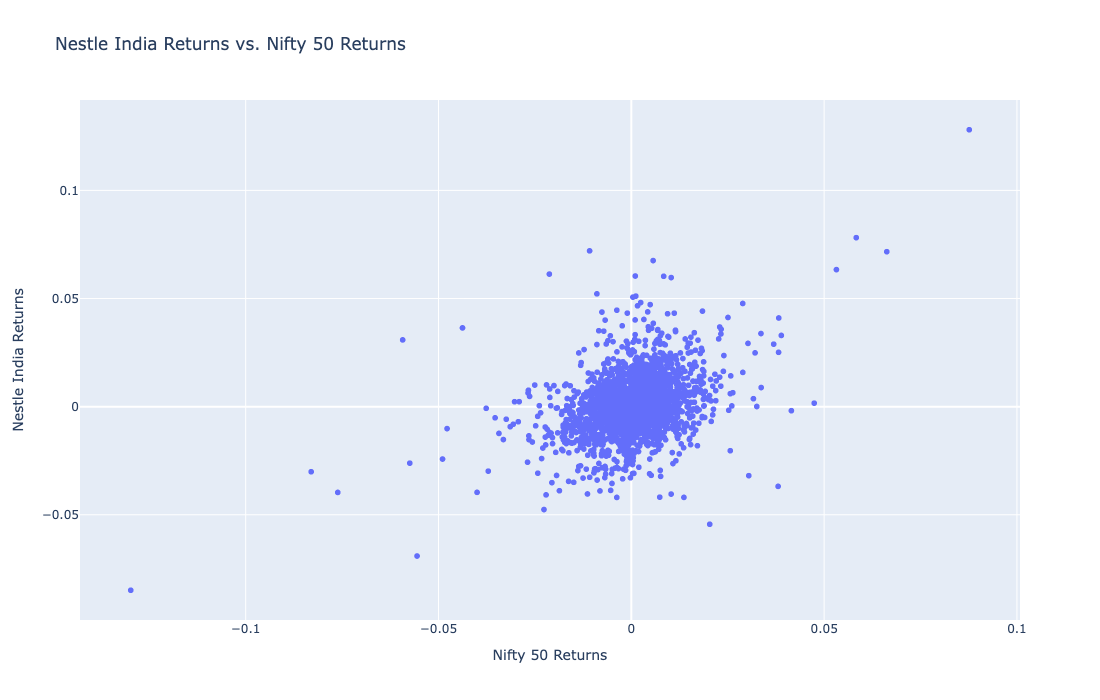

In [9]:
# First, we calculate the daily percentage change (returns) for both the stock and the market.
# The .dropna() function is used to remove the first row, which will be NaN after using pct_change().
data_pc = data.pct_change().dropna()

# Create an interactive scatter plot using Plotly
fig = px.scatter(data_pc, x='^NSEI', y='NESTLEIND.NS',
                 title='Nestle India Returns vs. Nifty 50 Returns',
                 labels={'^NSEI': 'Nifty 50 Returns', 'NESTLEIND.NS': 'Nestle India Returns'})

# Update layout for a cleaner look
fig.update_layout(
    xaxis_title='Nifty 50 Returns',
    yaxis_title='Nestle India Returns',
    showlegend=False,
    width=900,   # You can adjust the size as needed
    height=700    
    
)
fig.show()

### Step 4: Calculating Beta with Regression

The scatter plot gives us a good visual hint of a positive relationship. To get a precise number for this relationship, we'll perform an Ordinary Least Squares (OLS) regression. This statistical method finds the best-fitting line through the data points, and the slope of that line is our Beta.

In [10]:
# We'll use the 'statsmodels' library, a powerful tool for statistical modeling in Python.
import statsmodels.api as sm

# The OLS function takes the dependent variable (y) and the independent variable (x) as inputs.
# In our case, Y is the stock's returns and X is the market's returns.
line = sm.OLS(data_pc['NESTLEIND.NS'], data_pc['^NSEI'])

# .fit() performs the regression calculation.
line = line.fit()

# The beta is the coefficient of our independent variable (the market returns).
beta = line.params[0]

# Let's print our result in a user-friendly format!
f"The beta is {round(beta,2)}"

'The beta is 0.52'

### Interpreting the Beta

A beta of **0.52** indicates that Nestle India is significantly less volatile than the overall market (the Nifty 50).

Specifically, for every 1% move in the Nifty 50, we would historically expect Nestle India to move by about 0.52% in the same direction. This is a common characteristic for a large, stable company in a defensive sector like consumer goods. Investors might see it as a relatively 'safer' stock compared to the market as a whole during downturns, though it might also offer lower returns in a strong bull market.

### Step 5: Visualizing the Beta (The Regression Line)

Now, let's use Plotly to draw the best-fit regression line on our scatter plot. This will give us a clear, interactive visual representation of our calculated Beta and how well it fits the data.

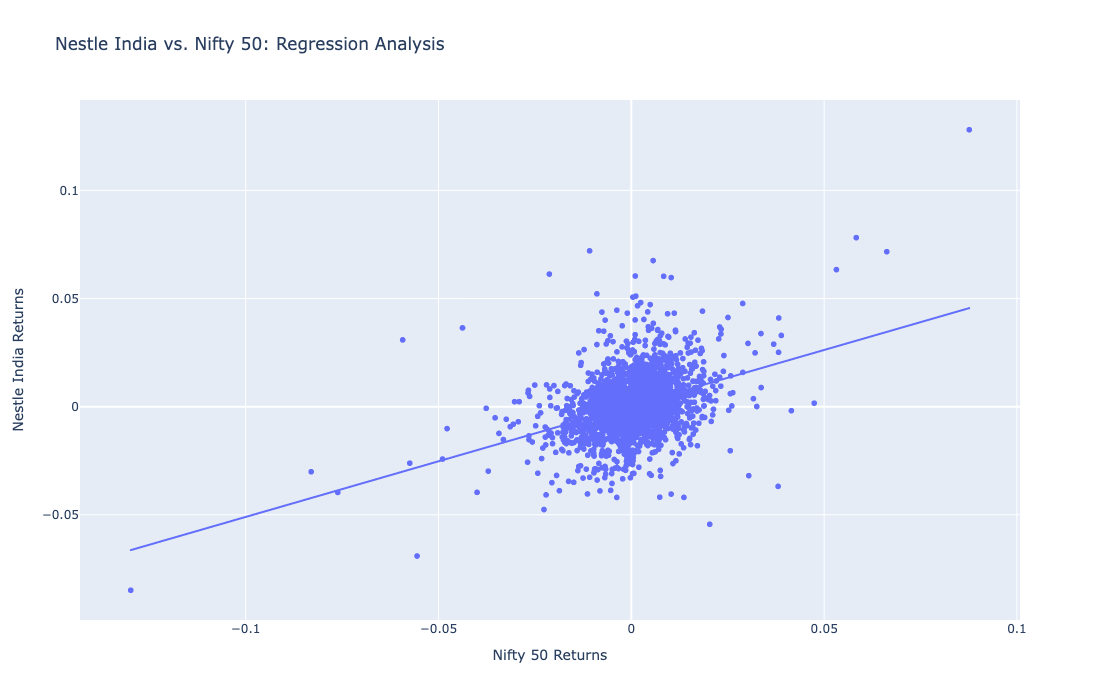

In [12]:
# Create an interactive scatter plot with an OLS regression line using Plotly
fig = px.scatter(data_pc, x='^NSEI', y='NESTLEIND.NS',
                 trendline="ols", # This adds the Ordinary Least Squares regression line
                 title='Nestle India vs. Nifty 50: Regression Analysis',
                 labels={'^NSEI': 'Nifty 50 Returns', 'NESTLEIND.NS': 'Nestle India Returns'})

# Update layout
fig.update_layout(
    xaxis_title='Nifty 50 Returns',
    yaxis_title='Nestle India Returns',
    showlegend=False,
    width=900,   # You can adjust the size as needed
    height=700
)
fig.show()

### Conclusion

In this notebook, we successfully calculated the beta for Nestle India against the Nifty 50 index. We started by gathering the price data, converted it to daily returns, and then used Ordinary Least Squares (OLS) linear regression to find the beta.

Our final calculated beta of approximately **0.52** quantitatively confirms that Nestle India has historically been about half as volatile as the broader market.

## Reference
[Beta Calculations](https://financetrain.com/calculating-beta-using-market-model-regression-slope/)